In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [30]:
z_list = [3, 1.5, 0.4, 0]
snapnum_list = [25, 40, 72, 99]

In [19]:
boxsize=205

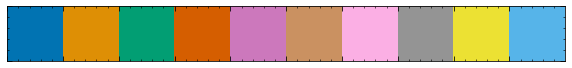

In [20]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [21]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [22]:
def gen_sums(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums = np.sum(10**sfr[mask])
        sums_list[ibin] = sums
    return bin_cents, np.array(sums_list), total

In [23]:
h = 0.6774

In [24]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [50]:
bin_cents_list = []
sums_cent_list = []
sums_sat_list = []
sums_group_list = []
total_group_list = []

for snapnum in snapnum_list:
    fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
               "Group_M_TopHat200"]
    header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
    halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)
    
    mvir = np.log10(halos["Group_M_TopHat200"]*1e10)
    
    group_sfrs = np.log10(halos["GroupSFR"])
    
    fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloMassType"] # [10^10 Msun/h]

    subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)

    cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
    cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True
    
    cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
    cent_sfrs = np.zeros(len(mvir))
    cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
    cent_sfrs = np.log10(cent_sfrs)
    
    sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]
    
    sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
    unique_ids, indices = np.unique(sat_ids, return_index=True)
    
    sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)
    
    sum_sfrs = np.zeros(len(group_sfrs))
    sum_sfrs[unique_ids] = sum_sfrs1
    sum_sfrs = np.log10(sum_sfrs)
    
    
    bin_edges_mhalo = np.arange(8.5, 15.5, 0.1)
    bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs, bin_edges_mhalo, mvir)
    bin_cents, sums_sat, total_sat = gen_sums(sum_sfrs, bin_edges_mhalo, mvir)
    bin_cents, sums_group, total_group = gen_sums(group_sfrs, bin_edges_mhalo, mvir)
    
    bin_cents_list.append(bin_cents)
    sums_cent_list.append(sums_cent)
    sums_sat_list.append(sums_sat)
    sums_group_list.append(sums_group)
    total_group_list.append(total_group)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in log10
  del sys.path[0]
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log10
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in log10


In [51]:
linestyles = ["dashdot", "solid", "dashed",  "dotted"]

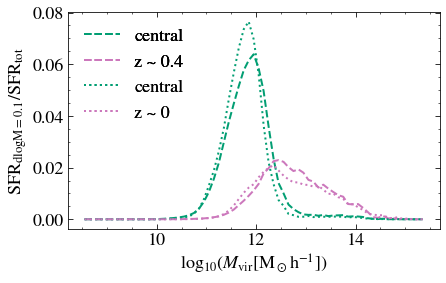

In [52]:

for i in [2,3]:
    bin_cents = bin_cents_list[i]
    sums_cent = sums_cent_list[i]
    sums_sat = sums_sat_list[i]
    sums_group = sums_group_list[i]
    total_group = total_group_list[i]
    
    #plt.plot(bin_cents, sums_group/total_group, label="Group", color=color_list[0])
    plt.plot(bin_cents, sums_cent/total_group, label="central", color=color_list[1], linestyle=linestyles[i])
    plt.plot(bin_cents, sums_sat/total_group, label=f"z ~ {z_list[i]}", color=color_list[2], linestyle=linestyles[i])
    ax = plt.gca()
    plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
    leg = ax.legend(loc="upper left")
    ax.add_artist(leg)
    plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")

    #vline = plt.vlines(mass, ymin=0, ymax=0.08, linestyle="dotted", color="grey", label="100 DM\nparticles")
    #plt.legend(handles=[vline], loc="lower right",bbox_to_anchor=(1,0.2))
    #ax.annotate("$\mathbf{z \sim 3}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
    #plt.savefig("../figures/contribution_continuous_sats_z.pdf", format="pdf", bbox_inches="tight")

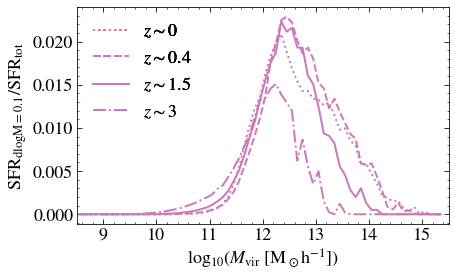

In [62]:

for i in [0,1,2,3][::-1]:
    bin_cents = bin_cents_list[i]
    sums_cent = sums_cent_list[i]
    sums_sat = sums_sat_list[i]
    sums_group = sums_group_list[i]
    total_group = total_group_list[i]
    
    #plt.plot(bin_cents, sums_group/total_group, label="Group", color=color_list[0])
    #plt.plot(bin_cents, sums_cent/total_group, label="Central", color=color_list[1])
    plt.plot(bin_cents, sums_sat/total_group, label=rf"$z \sim {z_list[i]}$", color=color_list[2], linestyle=linestyles[i])
    ax = plt.gca()
    plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
    leg = ax.legend(loc="upper left")
    ax.add_artist(leg)
    plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")
    plt.xlim(8.5,15.5)
    ax.set_xticks(np.arange(9,15.1,1))
    ax.set_xticks(np.arange(8.6,15.41, 0.2), minor=True)
    #vline = plt.vlines(mass, ymin=0, ymax=0.08, linestyle="dotted", color="grey", label="100 DM\nparticles")
    #plt.legend(handles=[vline], loc="lower right",bbox_to_anchor=(1,0.2))
    #ax.annotate("$\mathbf{z \sim 3}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
    #plt.savefig("../figures/contribution_continuous_sats_z.pdf", format="pdf", bbox_inches="tight")